# L=32 XY — three-phase raw PCA versus frozen ResNet-18

Raw PCA and frozen ResNet receive identical three-phase spin channels. Both comparisons below use the same PCA-fit indices, exact Lloyd K-means parameters, and silhouette evaluation observations. The first uses PCs 1–40 directly; the second uses only the PC1–PC2 radius.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

OUT=Path('/home/lledson/senior-thesis/data/processed/xy32_broad/matched_all_bins')
N_RUNS,N_T,BINS=10_000,41,10; N_CONFIGS=N_RUNS*N_T*BINS
RATIOS=np.array([.60,.70,.78,.84,.87,.89,.90,.91,.92,.93,.94,.95,.96,.97,.98,.99,1.,1.01,1.02,1.03,1.04,1.05,1.06,1.07,1.08,1.09,1.10,1.11,1.12,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.20,1.30,1.45,1.60,1.80])
temperature_ids=np.tile(np.repeat(np.arange(N_T,dtype=np.int8),BINS),N_RUNS)
fit_bins=(np.arange(N_RUNS)[:,None]+np.arange(N_T)[None,:])%BINS
FIT_INDICES=((np.arange(N_RUNS)[:,None]*N_T+np.arange(N_T)[None,:])*BINS+fit_bins).reshape(-1)
rng=np.random.default_rng(42); EVAL_INDICES=[]
for ti in range(N_T):
    candidates=((np.arange(N_RUNS)*N_T+ti)*BINS)[:,None]+np.arange(BINS)
    EVAL_INDICES.append(rng.choice(candidates.ravel(),125,replace=False))
EVAL_INDICES=np.concatenate(EVAL_INDICES)

raw_scores=np.load(OUT/'raw_threephase_pc1-40_scores.npy',mmap_mode='r')
res_scores=np.load(OUT/'resnet18_pc1-40_scores.npy',mmap_mode='r')

def features(scores,indices,mode):
    block=np.asarray(scores[indices,:40],dtype=np.float32)
    if mode=='radius_only': return np.sqrt(block[:,0]**2+block[:,1]**2)[:,None]
    return block

def exact_cluster(scores,prefix,mode):
    model=KMeans(2,random_state=42,n_init=10,max_iter=300,algorithm='lloyd').fit(features(scores,FIT_INDICES,mode))
    path=OUT/f'{prefix}_{mode}_matched_labels.npy'
    labels=np.lib.format.open_memmap(path,mode='w+',dtype=np.int8,shape=(N_CONFIGS,))
    for start in range(0,N_CONFIGS,100_000):
        stop=min(start+100_000,N_CONFIGS); labels[start:stop]=model.predict(features(scores,slice(start,stop),mode))
    labels.flush(); unordered=np.asarray(labels)
    means=[RATIOS[temperature_ids[unordered==k]].mean() for k in range(2)]
    order=np.argsort(means); mapping=np.empty(2,dtype=np.int8); mapping[order[0]]=0; mapping[order[1]]=1
    labels[:]=mapping[unordered]; labels.flush(); aligned=np.asarray(labels)
    pop=np.stack([(aligned.reshape(N_RUNS,N_T,BINS)==k).mean((0,2)) for k in range(2)])
    diag={'silhouette':float(silhouette_score(features(scores,EVAL_INDICES,mode),aligned[EVAL_INDICES])),'low_endpoint_high_cluster_fraction':float(pop[1,0]),'at_TBKT_high_cluster_fraction':float(pop[1,16]),'high_endpoint_high_cluster_fraction':float(pop[1,-1]),'iterations':int(model.n_iter_),'inertia':float(model.inertia_)}
    return labels,pop,diag

results={}
for mode in ('direct40','radius_only'):
    raw_labels,raw_pop,raw_diag=exact_cluster(raw_scores,'raw_threephase',mode)
    res_labels,res_pop,res_diag=exact_cluster(res_scores,'resnet18_threephase',mode)
    results[mode]={'raw_labels':raw_labels,'raw_pop':raw_pop,'raw_diag':raw_diag,'res_labels':res_labels,'res_pop':res_pop,'res_diag':res_diag,'AMI':float(adjusted_mutual_info_score(raw_labels,res_labels))}

raw_summary=json.loads((OUT/'raw_threephase_summary.json').read_text())
res_summary=json.loads((OUT/'resnet18_summary.json').read_text())
rows=[]
for mode,label in (('direct40','Direct PCs 1–40'),('radius_only','PC1–PC2 radius only')):
    result=results[mode]
    for representation,summary,diag in (('Raw three-phase PCA',raw_summary,result['raw_diag']),('Frozen ResNet-18, three-phase input',res_summary,result['res_diag'])):
        rows.append({'mode':label,'representation':representation,'PCs for 90% variance':summary['n90'],'silhouette':diag['silhouette'],'low-T high-cluster fraction':diag['low_endpoint_high_cluster_fraction'],'at TBKT high-cluster fraction':diag['at_TBKT_high_cluster_fraction'],'high-T high-cluster fraction':diag['high_endpoint_high_cluster_fraction'],'cross-representation AMI':result['AMI']})
comparison=pd.DataFrame(rows)
comparison.to_csv(OUT/'xy32_threephase_apples_to_apples_comparison.csv',index=False)
(OUT/'xy32_threephase_apples_to_apples_diagnostics.json').write_text(json.dumps({mode:{'raw':r['raw_diag'],'resnet':r['res_diag'],'AMI':r['AMI']} for mode,r in results.items()},indent=2))
comparison


,mode,representation,PCs for 90% variance,silhouette,low-T high-cluster fraction,at TBKT high-cluster fraction,high-T high-cluster fraction,cross-representation AMI
0,Direct PCs 1–40,Raw three-phase PCA,1158,0.223678,0.50074,0.50000,0.51218,0.384972
1,Direct PCs 1–40,"Frozen ResNet-18, three-phase input",43,0.181754,0.33434,0.54386,0.99738,0.384972
2,PC1–PC2 radius only,Raw three-phase PCA,1158,0.717534,0.00000,0.00100,1.00000,0.000675
3,PC1–PC2 radius only,"Frozen ResNet-18, three-phase input",43,0.575393,0.19614,0.54083,0.00978,0.000675


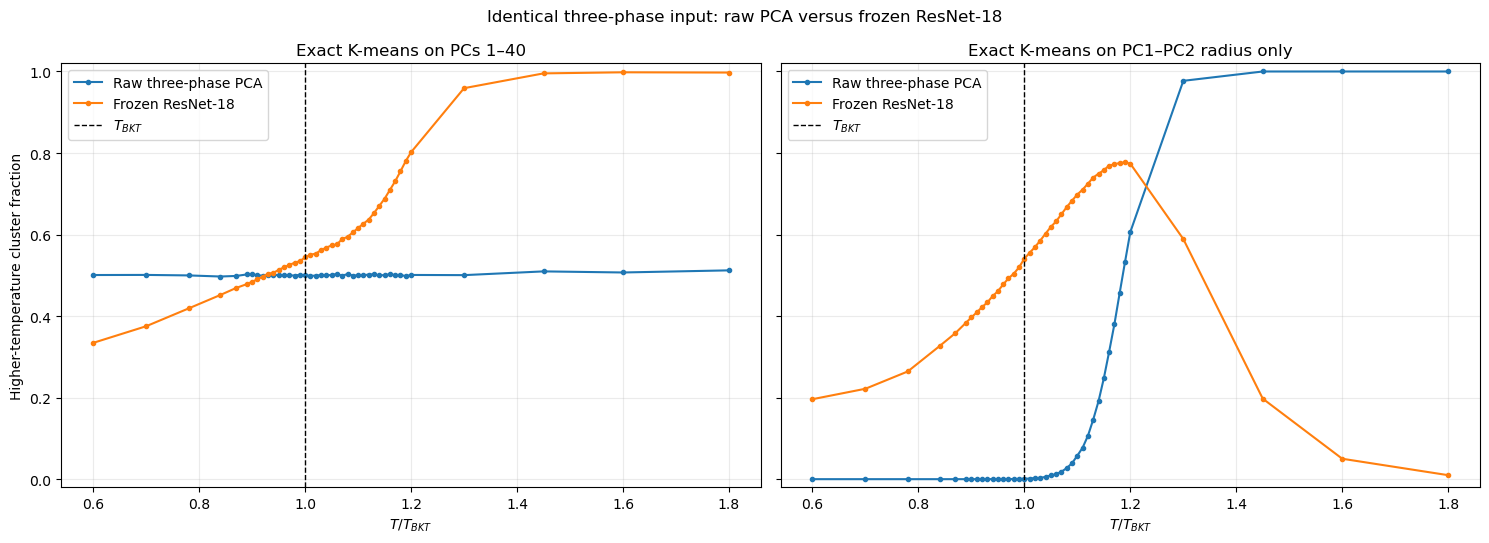

In [2]:
fig,axes=plt.subplots(1,2,figsize=(15,5.5),sharey=True)
for ax,(mode,title) in zip(axes,(('direct40','Exact K-means on PCs 1–40'),('radius_only','Exact K-means on PC1–PC2 radius only'))):
    result=results[mode]
    ax.plot(RATIOS,result['raw_pop'][1],'o-',ms=3,label='Raw three-phase PCA')
    ax.plot(RATIOS,result['res_pop'][1],'o-',ms=3,label='Frozen ResNet-18')
    ax.axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$')
    ax.set(xlabel=r'$T/T_{BKT}$',title=title,ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend()
axes[0].set_ylabel('Higher-temperature cluster fraction')
fig.suptitle('Identical three-phase input: raw PCA versus frozen ResNet-18')
fig.tight_layout(); fig.savefig(OUT/'xy32_threephase_apples_to_apples_cluster_comparison.png',dpi=220)
plt.show(); plt.close(fig)


## Interpretation

The input channels are now exactly matched. Direct 40-PC clustering tests the complete leading subspaces without imposing an XY symmetry quotient. Radius-only clustering applies the identical scalar postprocessing to both PC planes. Because the raw three-phase encoding is linearly equivalent to raw cos/sin, changes unique to ResNet reveal the effect of pretrained nonlinear image features rather than additional input information.